# Persistence — the closure hazard with duration dependence

How long does an arbitrage gap, once open, stay open? The closure branch of the
[existence equation](06_model_existence.ipynb) *already* answers this as a **discrete-time grouped
hazard**: restricting to `gap_lag > 0` and asking whether `D_t = 1` is, block by block, one
at-risk interval per row — "did the open spell survive this block?". The one thing the plain
closure hazard cannot see is **elapsed time**: every block of a spell is treated alike, whether it
is the spell's 1st or 8th.

This notebook adds that missing piece — `spell_duration`, the number of blocks the spell has
already survived (predetermined as of the block's own outcome) — turning the closure hazard into a
**duration-dependent** one (Wooldridge Ch. 20). One new covariate, the same estimator, 100 % of the
existing pipeline. All logic lives in `arblib.estimation`; this notebook only calls it.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

from arblib import estimation as est
from arblib.config import STUDY as S

panel = est.load_panel(S)
print("panel:", panel.shape)

panel: (4704, 28)


## Build the closure risk set

`build_risk_set(..., condition="closure")` keeps the rows where a gap is open at `t-1`
(`gap_lag > 0`) with outcome `D_t` = "the spell survived this block". Each row already carries the
predetermined `spell_duration` (spell age as of `t-1`, stamped once on the panel by
`add_spell_columns`) and a `spell_id` identifying the ongoing spell — the one open at `t-1`, so
consecutive within-spell rows, including the closing block, share a cluster.

In [2]:
clo = est.build_risk_set(panel, quantile=0.2, condition="closure")
clo["spell_duration"].value_counts().sort_index()

q20: dropping 15 pool pairs with no D variation (uninformative under pair FE): ['uniswap_1_vs_uniswap_4', 'uniswap_1_vs_uniswap_5', 'uniswap_2_vs_pancake_2', 'uniswap_2_vs_uniswap_3', 'uniswap_2_vs_uniswap_4', 'uniswap_2_vs_uniswap_5', 'uniswap_3_vs_pancake_1', 'uniswap_3_vs_pancake_2', 'uniswap_3_vs_uniswap_4', 'uniswap_3_vs_uniswap_5', 'uniswap_4_vs_pancake_1', 'uniswap_4_vs_pancake_2', 'uniswap_4_vs_uniswap_5', 'uniswap_5_vs_pancake_1', 'uniswap_5_vs_pancake_2']
closure: dropping 2 pairs: ['pancake_1_vs_pancake_2', 'uniswap_1_vs_uniswap_3']
closure: (75, 17) | D mean: 0.5467 | pairs: 4 | spell_duration max: 4


spell_duration
1.0    35
2.0    20
3.0    13
4.0     7
Name: count, dtype: int64

In [3]:
CONT = ["gap_lag", "log_base_fee", "gas_util_lag", "tip_p90_lag",
        "mev_lag", "freq_lag", "log_vol", "dlogL_lag", "spell_duration"]
clo_c = est.center_continuous(clo, CONT)

dur = est.fit_hazard_logit(clo_c, est.CLOSURE_DURATION_TERMS, cluster="pair")
print(dur.summary())

                           Logit Regression Results                           
Dep. Variable:                      D   No. Observations:                   75
Model:                          Logit   Df Residuals:                       62
Method:                           MLE   Df Model:                           12
Date:                Thu, 06 Aug 2026   Pseudo R-squ.:                  0.3386
Time:                        19:13:13   Log-Likelihood:                -34.166
converged:                       True   LL-Null:                       -51.659
Covariance Type:              cluster   LLR p-value:                 0.0004706
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             0.8032      0.328      2.449      0.014       0.160       1.446
C(pair)[T.uniswap_1_vs_pancake_2]    -0.8507      0.806     -1

In [4]:
clo_c

,pair,evt_block_number,evt_block_time,D,gap_lag,log_base_fee,gas_util_lag,tip_p90_lag,mev_lag,freq_lag,log_vol,dlogL_lag,spell_duration,hour,dow,week,spell_id
0,uniswap_1_vs_pancake_1,24131949,2025-12-31 10:16:11+00:00,1.0,-0.837802,-0.104770,-0.067528,0.188913,-0.306338,-0.171104,-0.166504,-0.001345,-0.893333,10,2,1,uniswap_1_vs_pancake_1_q20_1
1,uniswap_1_vs_pancake_1,24131950,2025-12-31 10:16:23+00:00,1.0,-0.837802,-0.032704,0.274354,-0.117848,-0.373005,-0.204427,-0.166504,-0.001345,0.106667,10,2,1,uniswap_1_vs_pancake_1_q20_1
2,uniswap_1_vs_pancake_1,24131951,2025-12-31 10:16:35+00:00,1.0,-0.837802,-0.067508,-0.161378,-0.166557,-0.439671,-0.235601,-0.166504,-0.001345,1.106667,10,2,1,uniswap_1_vs_pancake_1_q20_1
3,uniswap_1_vs_pancake_1,24131952,2025-12-31 10:16:47+00:00,0.0,-0.837802,-0.170503,-0.416029,0.154147,-0.506338,-0.264764,-0.166504,-0.001345,2.106667,10,2,1,uniswap_1_vs_pancake_1_q20_1
4,uniswap_1_vs_pancake_1,24131954,2025-12-31 10:17:11+00:00,0.0,-0.265123,-0.086910,-0.061490,0.174898,-0.312407,-0.069995,-0.176601,-0.001345,-0.893333,10,2,1,uniswap_1_vs_pancake_1_q20_3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,uniswap_2_vs_pancake_1,24132095,2025-12-31 10:45:23+00:00,1.0,0.904944,0.010287,-0.009745,0.243458,-0.693702,-0.509450,0.024526,-0.001345,1.106667,10,2,1,uniswap_2_vs_pancake_1_q20_5
71,uniswap_2_vs_pancake_1,24132096,2025-12-31 10:45:35+00:00,0.0,0.904944,-0.022876,-0.155031,0.243458,-0.760368,-0.520952,0.024526,-0.001345,2.106667,10,2,1,uniswap_2_vs_pancake_1_q20_5
72,uniswap_2_vs_pancake_1,24132165,2025-12-31 10:59:23+00:00,1.0,-0.549678,0.090355,-0.097305,-0.391978,-1.793122,-0.493012,-0.044957,0.002524,-0.893333,10,2,1,uniswap_2_vs_pancake_1_q20_7
73,uniswap_2_vs_pancake_1,24132166,2025-12-31 10:59:35+00:00,1.0,-0.549678,-0.001604,-0.375985,0.243458,-1.859789,-0.505574,-0.044957,-0.001345,0.106667,10,2,1,uniswap_2_vs_pancake_1_q20_7


In [5]:
est.average_marginal_effects(dur, est.CLOSURE_DURATION_TERMS)

,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
gap_lag,0.053763,0.039412,1.364113,1.725321e-01,-0.023484,0.131010
log_base_fee,1.192342,0.453847,2.627187,8.609406e-03,0.302817,2.081866
gas_util_lag,-0.312962,0.070434,-4.443336,8.857463e-06,-0.451011,-0.174914
tip_p90_lag,-0.404480,0.056472,-7.162544,7.919366e-13,-0.515162,-0.293798
mev_lag,-0.092752,0.112011,-0.828062,4.076352e-01,-0.312290,0.126785
freq_lag,-1.608483,0.214605,-7.495082,6.625691e-14,-2.029101,-1.187864
log_vol,1.383414,1.030803,1.342074,1.795719e-01,-0.636923,3.403751
dlogL_lag,-13.184169,7.730816,-1.705404,8.811902e-02,-28.336290,1.967953
spell_duration,-0.223577,0.037434,-5.972590,2.335163e-09,-0.296945,-0.150208


## Spell-level view — Kaplan–Meier survival (lifelines)

Everything above is a *block-level* at-risk table (one row per open block). The classic survival
view takes the **spell** as the unit, so the dataframe has to be reshaped. `build_spell_table`
collapses the panel's canonical spells (`spell_id` / `spell_duration` from `add_spell_columns`) into
one row per spell:

- `duration` — the spell length in blocks (its final `spell_duration`);
- `observed` — lifelines' `event_observed`: `1` if closure is seen (the run is followed by a
  `Gap == 0` block), `0` if the spell is **right-censored** (its last block is the pair's last block
  in the window, so its true length is unknown).

That `observed` flag is the one thing the block panel never made explicit — the reshape is exactly
what turns "rows that just stop" into a proper censoring indicator. It is descriptive (no fixed
effects, no pair screening), so it keeps every spell across all pairs.

In [6]:
spells = est.build_spell_table(panel, quantile=0.2)
spells.head()

spells: 39 | closed: 36 | censored: 3 | left-truncated: 0 | median duration: 2.0


,pair,onset_block,last_block,duration,observed,left_truncated
0,pancake_1_vs_pancake_2,24132166,24132167,2,0,False
1,uniswap_1_vs_pancake_1,24131948,24131951,4,1,False
2,uniswap_1_vs_pancake_1,24131953,24131953,1,1,False
3,uniswap_1_vs_pancake_1,24131960,24131960,1,1,False
4,uniswap_1_vs_pancake_1,24131971,24131971,1,1,False


Fit the Kaplan–Meier estimator on `(duration, observed)` and read off
`S(t) = P(spell still open after t blocks)`. In this one-hour window nothing is censored (no spell
outlives the extraction), so the curve is the raw empirical survival — but the identical call handles
right-censoring unchanged on a longer sample.

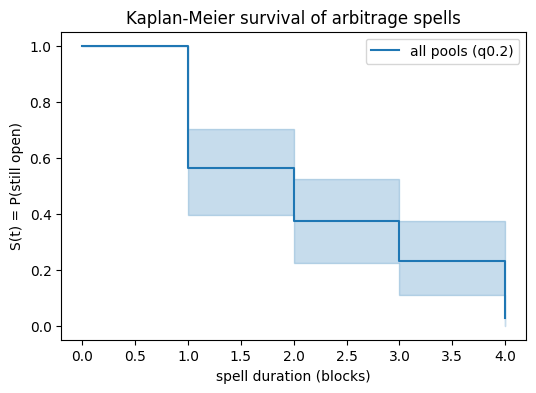

median survival (blocks): 2.0


,all pools (q0.2),all pools (q0.2)_lower_0.95,all pools (q0.2)_upper_0.95
timeline,,,
0.0,1.0000,1.0000,1.0000
1.0,0.5641,0.3957,0.7022
2.0,0.3761,0.2262,0.5255
3.0,0.2314,0.1113,0.3770
4.0,0.0289,0.0022,0.1279


In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(spells["duration"], event_observed=spells["observed"], label="all pools (q0.2)")

ax = kmf.plot_survival_function(figsize=(6, 4))
ax.set_xlabel("spell duration (blocks)"); ax.set_ylabel("S(t) = P(still open)")
ax.set_title("Kaplan-Meier survival of arbitrage spells")
plt.show()

print("median survival (blocks):", kmf.median_survival_time_)
kmf.survival_function_.join(kmf.confidence_interval_).round(4)